Decision Trees and Random Forests

In [ ]:
# Load and preprocess the data
import pandas as pd
from sklearn.model_selection import train_test_split

# Load Data
data = pd.read_csv("heart.csv")

# Separate the features and target
x = data.drop("target", axis=1)
y = data["target"]

# Train Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

 1.Train a Decision Tree Classifier and visualize the tree.

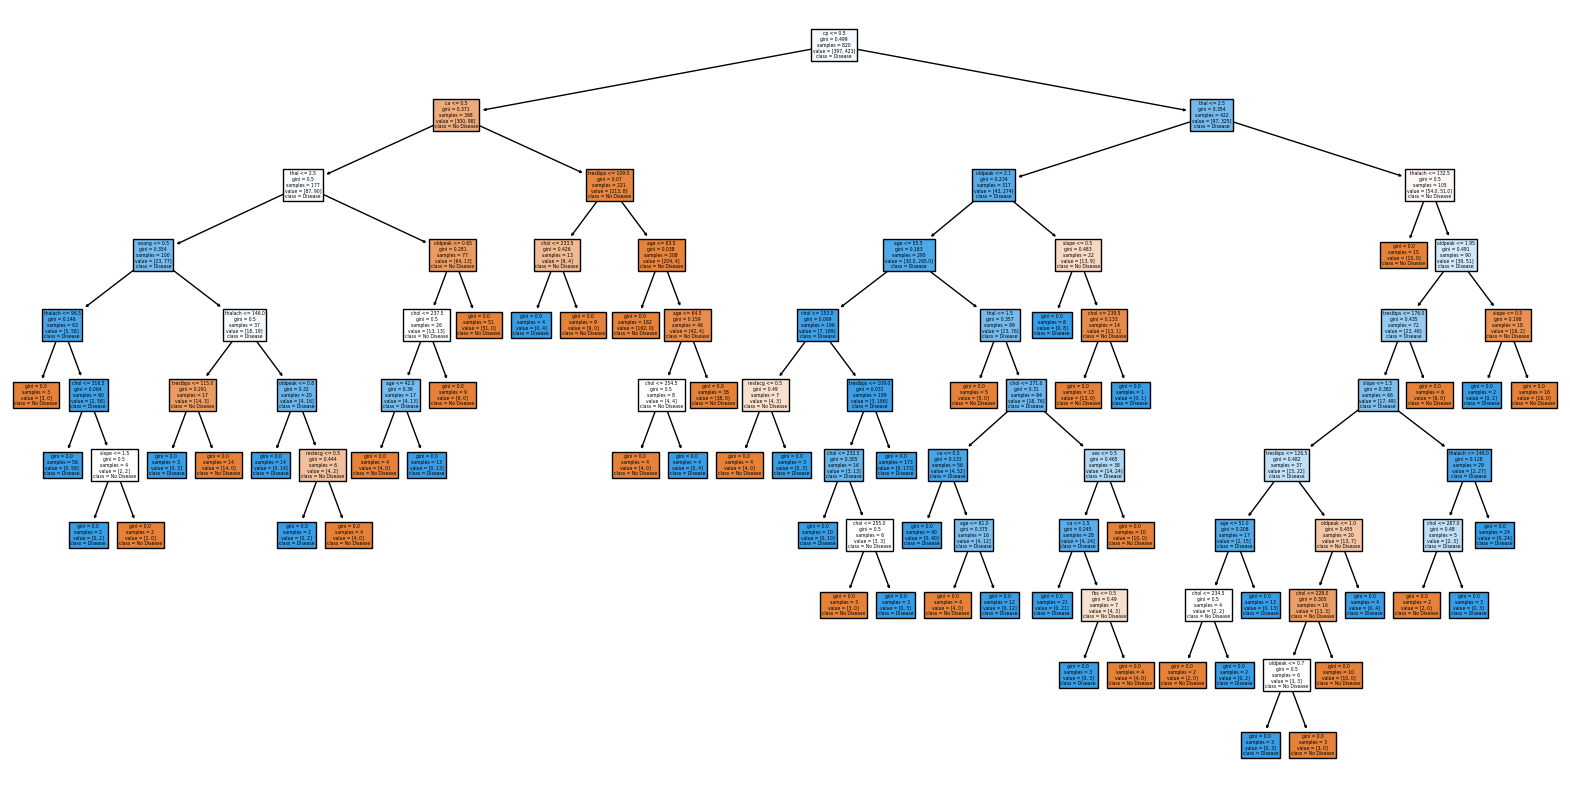

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, feature_names=x.columns, class_names=["No Disease", "Disease"])
plt.show()

 2.Analyze overfitting and control tree depth.

In [5]:
from sklearn.metrics import accuracy_score

# Evaluate default tree
train_acc = accuracy_score(y_train, dt.predict(x_train))
test_acc = accuracy_score(y_test, dt.predict(x_test))

# Limit depth to control overfitting
dt_limited = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_limited.fit(x_train, y_train)
limited_test_acc = accuracy_score(y_test, dt_limited.predict(x_test))

print("Training Accuracy (Full Tree):", train_acc)
print("Testing Accuracy (Full Tree):", test_acc)
print("Testing Accuracy (Limited Depth):", limited_test_acc)


Training Accuracy (Full Tree): 1.0
Testing Accuracy (Full Tree): 0.9853658536585366
Testing Accuracy (Limited Depth): 0.8


 3.Train a Random Forest and compare accuracy.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

# Accuracy comparison
rf_train_acc = accuracy_score(y_train, rf.predict(x_train))
rf_test_acc = accuracy_score(y_test, rf.predict(x_test))


print("Random Forest Training Accuracy:", rf_train_acc)
print("Random Forest Testing Accuracy:", rf_test_acc)

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.9853658536585366


 4.Interpret feature importances.

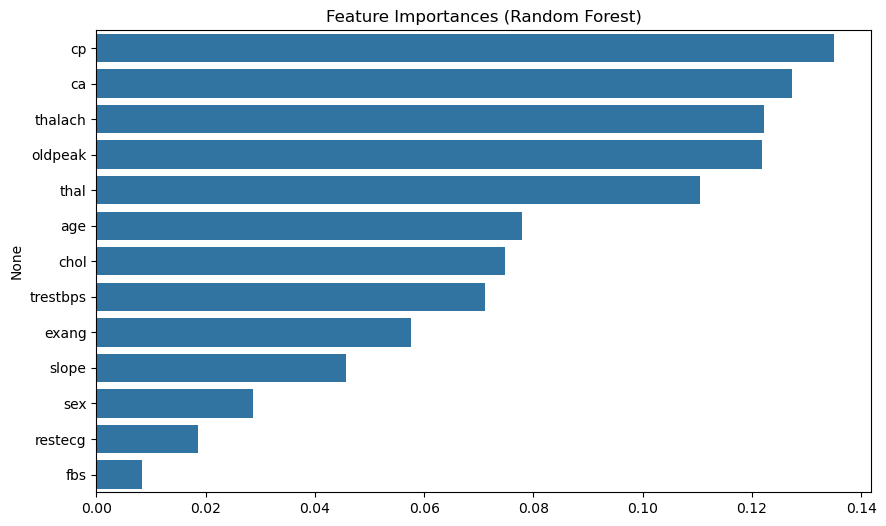

In [7]:
import seaborn as sns
import numpy as np

# Get importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=x.columns[indices])
plt.title("Feature Importances (Random Forest)")
plt.show()

 5.Evaluate using cross-validation.

In [8]:
from sklearn.model_selection import cross_val_score

# Cross-validation scores
dt_scores = cross_val_score(dt_limited, x, y, cv=5)
rf_scores = cross_val_score(rf, x, y, cv=5)

print("Decision Tree CV Accuracy (max_depth=4):", dt_scores.mean())
print("Random Forest CV Accuracy:", rf_scores.mean())

Decision Tree CV Accuracy (max_depth=4): 0.8341463414634147
Random Forest CV Accuracy: 0.9970731707317073


Summary
| Model             | Train Acc | Test Acc | CV Acc |
|------------------|-----------|----------|--------|
| Decision Tree     | High (overfit) | Lower | ~varies |
| Limited Depth Tree | Lower    | Better   | Moderate |
| Random Forest     | High     | Best     | Highest |